#  MuJoCo Bootcamp : Projectile with drag

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---

### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/Ga3twtlgKsM

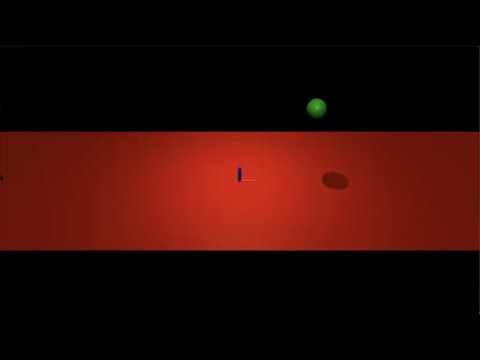

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('Ga3twtlgKsM')

## Run python code

In [ ]:
!python projectile.py

## Jupyter code

### Load XML file and build model and data

In [2]:
import mujoco as mj
import numpy as np
import mediapy as media

# Create an XML file string for a simple ball on a plane
xml_path = "./ball.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [3]:
def controller(model, data):
    """
    This controller adds drag force to the ball.
    F = -c * v * |v|
    """
    vx, vy, vz = data.qvel[0], data.qvel[1], data.qvel[2]
    v = np.sqrt(vx**2 + vy**2 + vz**2)
    if v > 1e-6: # Avoid division by zero
        c = 1.0
        data.qfrc_applied[0] = -c * v * vx
        data.qfrc_applied[1] = -c * v * vy
        data.qfrc_applied[2] = -c * v * vz

# Set the controller
mj.set_mjcb_control(controller)


### Setup the configuration of render

In [4]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()
mj.mjv_defaultCamera(cam)
cam.azimuth = 90.0
cam.distance = 8.0
cam.elevation = -45.0


### Initialization 

In [5]:
# Reset the data to initial state
mj.mj_resetData(model, data)

# Set initial ball conditions
data.qpos[2] = 0.7
data.qvel[0] = 2.0
data.qvel[2] = 5.0

### Simulation

In [6]:
# Store frames for visualization
frames = []
framerate = 60
simend = 5

while data.time < simend:
    # Perform a single simulation step
    simstart = data.time

    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)